In [ ]:
# %pip install torch torchvision numpy matplotlib gdown
import copy
import math
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import clear_output
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 42
STEPS = 100000
BATCH_SIZE = 64
STEP_RECORD = 250
N_TRAIN_EVAL = 1000
HIDDEN_CHANNELS = 64
N_BLOCKS = 2
LR = 1e-3
TEMPERATURE = 1.0

DEVICE = torch.device("cuda:6" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
print(f"PyTorch {torch.__version__} | {DEVICE} | seed={SEED}")

CHANNELS, HEIGHT, WIDTH = 3, 64, 64

DATA_ROOT = "/home/iasudakov/scince_school/data"

celeba_transform = transforms.Compose([
    transforms.CenterCrop(148),
    transforms.Resize(HEIGHT),
    transforms.PILToTensor(),
])


def load_celeba(split):
    cache = os.path.join(DATA_ROOT, f"celeba{HEIGHT}_{split}.pt")
    if os.path.exists(cache):
        return torch.load(cache)
    dataset = datasets.CelebA(DATA_ROOT, split=split, target_type="identity",
                              transform=celeba_transform, download=False)
    loader = DataLoader(dataset, batch_size=512, num_workers=8)
    images = torch.empty(len(dataset), CHANNELS, HEIGHT, WIDTH, dtype=torch.uint8)
    filled = 0
    for batch, _ in loader:
        images[filled:filled + len(batch)] = batch
        filled += len(batch)
    torch.save(images, cache)
    return images


x_train = load_celeba("train")
x_val = load_celeba("valid")
print(f"train: {tuple(x_train.shape)}, valid: {tuple(x_val.shape)}")


def to_float(images):
    return images.float() / 255


def augment_batch(images):
    flip = torch.rand(len(images), device=images.device) < 0.5
    images = images.clone()
    images[flip] = images[flip].flip(-1)
    return images


def dequantize(x):
    return (255 * x + torch.rand_like(x)) / 256

PyTorch 2.6.0+cu124 | cuda:6 | seed=42
train: (162770, 3, 64, 64), valid: (19867, 3, 64, 64)


In [2]:
def show_images(images, ncols=5, size=1.6):
    images = images.detach().cpu().clamp(0, 1).permute(0, 2, 3, 1).numpy()
    nrows = math.ceil(len(images) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * size, nrows * size))
    for ax in np.ravel(axes):
        ax.axis("off")
    for ax, image in zip(np.ravel(axes), images):
        ax.imshow(image)
    plt.tight_layout()
    plt.show()

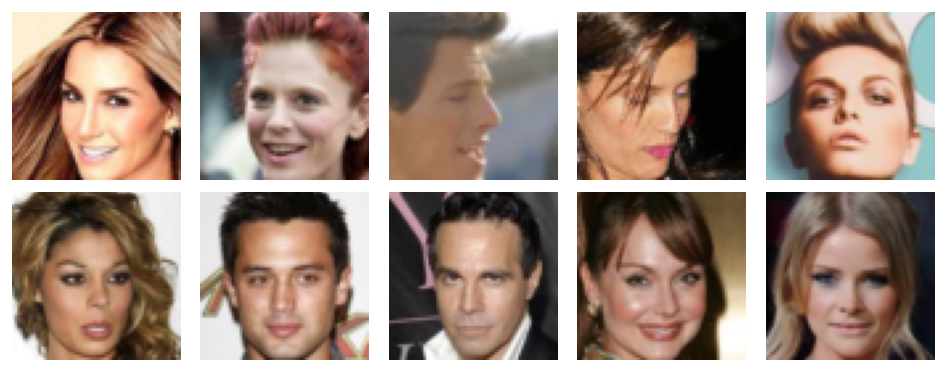

In [3]:
show_images(to_float(x_train[:10]))

In [ ]:
def squeeze(x):
    B, C, H, W = x.shape
    x = x.reshape(B, C, H // 2, 2, W // 2, 2)
    x = x.permute(0, 3, 5, 1, 2, 4)
    return x.reshape(B, 4 * C, H // 2, W // 2)


def unsqueeze(x):
    B, C4, H2, W2 = x.shape
    x = x.reshape(B, 2, 2, C4 // 4, H2, W2)
    x = x.permute(0, 3, 4, 1, 5, 2)
    return x.reshape(B, C4 // 4, H2 * 2, W2 * 2)


class Squeeze(nn.Module):
    def forward(self, x, inverse=False):
        return (unsqueeze(x) if inverse else squeeze(x)), 0


class Split(nn.Module):
    pass


class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
        )

    def forward(self, x):
        return x + self.net(x)


def conv_net(c_in, c_out, hidden, n_blocks):
    layers = [nn.Conv2d(c_in, hidden, 3, padding=1), nn.ReLU()]
    for _ in range(n_blocks):
        layers.append(ResBlock(hidden))
        layers.append(nn.ReLU())
    layers.append(nn.Conv2d(hidden, c_out, 3, padding=1))
    bn = nn.BatchNorm2d(c_out)
    nn.init.zeros_(bn.weight)
    layers.append(bn)
    return nn.Sequential(*layers)


class CouplingNorm(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.register_buffer("running_mean", torch.zeros(channels))
        self.register_buffer("running_var", torch.ones(channels))

    def forward(self, x, mask=1, inverse=False):
        if self.training:
            variance, mean = torch.var_mean(x * mask, dim=(0, 2, 3), unbiased=False)
            with torch.no_grad():
                self.running_mean.lerp_(mean.detach(), 0.1)
                self.running_var.lerp_(variance.detach(), 0.1)
        else:
            mean, variance = self.running_mean, self.running_var
        shift = mean[None, :, None, None] * mask
        log_scale = -0.5 * (variance + 1e-4).log()[None, :, None, None] * mask
        y = x * (-log_scale).exp() + shift if inverse else (x - shift) * log_scale.exp()
        logdet = log_scale.expand_as(x).flatten(1).sum(dim=1)
        return y, -logdet if inverse else logdet


class CheckerCoupling(nn.Module):
    def __init__(self, c, h, w, parity, hidden, n_blocks):
        super().__init__()
        self.parity = parity
        self.net = conv_net(c, 2 * c, hidden, n_blocks)
        self.bn_out = CouplingNorm(c)
        self.scale = nn.Parameter(torch.ones(c, h, w))

    def forward(self, x, inverse=False):
        H, W = x.shape[2], x.shape[3]
        i = torch.arange(H, device=x.device).view(-1, 1)
        j = torch.arange(W, device=x.device).view(1, -1)
        b = ((i + j) % 2 == self.parity).to(x.dtype)

        s, t = self.net(x * b).chunk(2, dim=1)
        s = self.scale * torch.tanh(s) * (1 - b)
        t = t * (1 - b)
        logdet = s.flatten(1).sum(dim=1)

        if inverse:
            x, norm_ld = self.bn_out(x, mask=1 - b, inverse=True)
            return (x - t) * torch.exp(-s), norm_ld - logdet

        y, norm_ld = self.bn_out(x * torch.exp(s) + t, mask=1 - b)
        return y, logdet + norm_ld


class ChannelCoupling(nn.Module):
    def __init__(self, c, h, w, swap, hidden, n_blocks):
        super().__init__()
        self.swap = swap
        self.net = conv_net(c // 2, 2 * (c // 2), hidden, n_blocks)
        self.bn_out = CouplingNorm(c // 2)
        self.scale = nn.Parameter(torch.ones(c // 2, h, w))

    def forward(self, x, inverse=False):
        a, b = x.chunk(2, dim=1)
        if self.swap:
            a, b = b, a

        s, t = self.net(a).chunk(2, dim=1)
        s = self.scale * torch.tanh(s)
        logdet = s.flatten(1).sum(dim=1)

        if inverse:
            b, norm_ld = self.bn_out(b, inverse=True)
            b = (b - t) * torch.exp(-s)
            logdet = norm_ld - logdet
        else:
            b, norm_ld = self.bn_out(b * torch.exp(s) + t)
            logdet = logdet + norm_ld
        if self.swap:
            a, b = b, a
        return torch.cat([a, b], dim=1), logdet


class RealNVP(nn.Module):
    def __init__(self, c, h, w, hidden_channels=64, n_blocks=2, n_scales=4, max_hidden=256, alpha=0.05):
        super().__init__()
        self.n = c * h * w

        layers, z_shapes = [], []
        hid = hidden_channels
        for _ in range(n_scales):
            layers += [CheckerCoupling(c, h, w, i % 2, hid, n_blocks) for i in range(3)]
            layers.append(Squeeze())
            c, h, w = 4 * c, h // 2, w // 2
            layers += [ChannelCoupling(c, h, w, i % 2, hid, n_blocks) for i in range(3)]
            layers.append(Split())
            c = c // 2
            z_shapes.append((c, h, w))
            hid = min(2 * hid, max_hidden)

        layers += [CheckerCoupling(c, h, w, i % 2, hid, n_blocks) for i in range(4)]
        z_shapes.append((c, h, w))

        self.layers = nn.ModuleList(layers)
        self.z_shapes = z_shapes
        self.log_scale = nn.Parameter(torch.zeros(self.n))
        self.alpha = alpha

    def to_logit(self, x):
        p = (self.alpha + (1 - self.alpha) * x).clamp(max=1 - 1e-6)
        log_p, log_1mp = p.log(), torch.log(1 - p)
        log_det = (math.log(1 - self.alpha) - log_p - log_1mp).flatten(1).sum(dim=1)
        return log_p - log_1mp, log_det

    def from_logit(self, y):
        return (torch.sigmoid(y) - self.alpha) / (1 - self.alpha)

    def forward(self, x):
        x, log_det = self.to_logit(x)
        zs = []
        for layer in self.layers:
            if isinstance(layer, Split):
                z_out, x = x.chunk(2, dim=1)
                zs.append(z_out.flatten(1))
            else:
                x, ld = layer(x)
                log_det = log_det + ld
        zs.append(x.flatten(1))
        z = torch.cat(zs, dim=1) * self.log_scale.exp()
        return z, log_det + self.log_scale.sum()

    def inverse(self, z):
        z = z * (-self.log_scale).exp()
        parts = list(torch.split(z, [math.prod(s) for s in self.z_shapes], dim=1))
        x = parts.pop().reshape(-1, *self.z_shapes[-1])
        for layer in reversed(self.layers):
            if isinstance(layer, Split):
                shape = self.z_shapes[len(parts) - 1]
                x = torch.cat([parts.pop().reshape(-1, *shape), x], dim=1)
            else:
                x, _ = layer(x, inverse=True)
        return self.from_logit(x)

    def log_prob(self, x):
        z, log_det = self(x)
        log_base = -0.5 * (z.square() + math.log(2 * math.pi)).sum(dim=1)
        return log_base + log_det

    @torch.no_grad()
    def sample(self, batch_size, temperature=1.0):
        z = temperature * torch.randn(batch_size, self.n, device=self.log_scale.device)
        return self.inverse(z)


model = RealNVP(CHANNELS, HEIGHT, WIDTH, hidden_channels=HIDDEN_CHANNELS, n_blocks=N_BLOCKS).to(DEVICE)

In [5]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total params: {total_params}")

Total params: 46014398


In [ ]:
x_train = x_train.to(DEVICE)
x_val = x_val.to(DEVICE)

x_train_eval = x_train[torch.randperm(len(x_train))[:N_TRAIN_EVAL]]
x_val_eval = x_val

def make_optimizer(model, lr=LR, scale_weight_decay=5e-5):
    scales = [p for n, p in model.named_parameters() if n.endswith(".scale")]
    others = [p for n, p in model.named_parameters() if not n.endswith(".scale")]
    return torch.optim.Adam([
        {"params": others},
        {"params": scales, "weight_decay": scale_weight_decay},
    ], lr=lr)

optimizer = make_optimizer(model)
history = []

@torch.no_grad()
def mean_nll(x, chunk_size=250):
    was_training = model.training
    model.eval()
    try:
        # Фиксированный шум деквантизации, чтобы NLL между замерами был сравним
        generator = torch.Generator(device=x.device).manual_seed(SEED)
        total = 0.0
        for start in range(0, len(x), chunk_size):
            chunk = to_float(x[start:start + chunk_size])
            noise = torch.rand(
                chunk.shape, generator=generator, device=chunk.device
            )
            chunk = (255 * chunk + noise) / 256
            total += -model.log_prob(chunk).sum().item()
        return total / len(x)
    finally:
        model.train(was_training)


def bits_per_dim(nll):
    # nll в натах на изображение для данных в [0, 1]; переводим к дискретным пикселям 0..255
    return (nll + model.n * math.log(256)) / (model.n * math.log(2))


def record(step):
    history.append((step, mean_nll(x_train_eval), mean_nll(x_val_eval)))


def plot_history(title):
    points = np.array(history[1:])
    fig, ax = plt.subplots(figsize=(6.5, 2.6), layout="constrained")
    ax.plot(points[:, 0], bits_per_dim(points[:, 1]), label="Обучающая", color="#2878B5", marker="o", markersize=3)
    ax.plot(points[:, 0], bits_per_dim(points[:, 2]), label="Проверочная", color="#E07A3F", marker="o", markersize=3)
    ax.axvline(best_step, color="gray", linestyle="--", linewidth=1, label="Лучшая модель")
    ax.set(xlabel="Шаг", ylabel="Bits/dim", title=title)
    ax.legend(frameon=False, fontsize=8)
    plt.show()


with torch.no_grad():
    z_start, _ = model(dequantize(to_float(x_train_eval[:1000])))
    model.log_scale.copy_(-z_start.std(0).clamp_min(1e-3).log())

record(0)
best_val_nll = history[0][2]
best_step = 0
best_state = copy.deepcopy(model.state_dict())
steps_done = 0
print(f"NLL до обучения: train {history[0][1]:.1f}, val {history[0][2]:.1f}")

In [ ]:
first_step = steps_done + 1
last_step = steps_done + STEPS

# Один и тот же шум для сравнения картинок по ходу обучения
preview_z = torch.randn(10, model.n, generator=torch.Generator().manual_seed(SEED)).to(DEVICE)

started = time.perf_counter()
model.train()
for step in range(first_step, last_step + 1):
    indices = torch.randint(len(x_train), (BATCH_SIZE,), device=DEVICE)
    batch = augment_batch(to_float(x_train[indices]))
    batch = dequantize(batch)

    loss = -model.log_prob(batch).mean()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    steps_done = step

    if step % STEP_RECORD == 0:
        record(step)
        val_nll = history[-1][2]
        if val_nll < best_val_nll:
            best_val_nll = val_nll
            best_step = step
            best_state = copy.deepcopy(model.state_dict())

        elapsed = time.perf_counter() - started
        clear_output(wait=True)
        plot_history(f"Шаг {step} из {last_step} · {elapsed:.0f} с · val {bits_per_dim(val_nll):.3f} bits/dim")
        model.eval()
        with torch.no_grad():
            show_images(model.inverse(TEMPERATURE * preview_z))
        model.train()
model.eval()

print(f"Этот запуск: {time.perf_counter() - started:.1f} с; всего шагов: {steps_done}")
print(f"NLL (val): {history[0][2]:.3f} -> {best_val_nll:.3f} нат/изображение (лучший шаг {best_step})")

In [ ]:
torch.save(model.state_dict(), "realnvp_weights_celeba.pt")

In [ ]:
model.load_state_dict(best_state)
model.eval()
print(f"Загружена лучшая модель: шаг {best_step}, val NLL {best_val_nll:.1f}")

In [ ]:
with torch.no_grad():
    # сдвигаем их ближе к нулю чтобы более вероятные(более реальные) картинки генерились
    generated = model.sample(10, temperature=TEMPERATURE)

show_images(generated)

In [ ]:
# from google.colab import files

torch.save(model.state_dict(), "realnvp_weights.pt")
# files.download("realnvp_weights.pt")